# Replication of paper "The Evolution of Language (Nowak & Krakauer, 1999)"

# 1. Introduction

Human language is one of the defining characteristics of our species. Unlike animal communication systems, human languages possess enormous expressive power, allowing speakers to communicate an effectively unlimited number of ideas using a finite set of sounds and grammatical rules. Understanding how such a system evolved from simpler communication mechanisms remains one of the central problems in evolutionary theory.

Traditional explanations of language evolution often begin with features of modern language and attempt to identify their adaptive advantages. However, such approaches provide little insight into how language initially emerged in populations that lacked any sophisticated communication system. Nowak and Krakauer addressed this problem by proposing an evolutionary framework capable of explaining how increasingly complex forms of communication could emerge gradually through natural selection.

Their theory is based on evolutionary game theory, where communication success directly influences reproductive fitness. Individuals capable of communicating more effectively obtain higher payoffs and therefore contribute more offspring to subsequent generations. Over time, successful communication strategies spread throughout the population, leading to the emergence of stable language systems.

The paper investigates three major evolutionary transitions. First, it explores how associations between signals and objects can emerge spontaneously within a population. Second, it examines the effects of communication errors and demonstrates the existence of a linguistic error limit that constrains simple protolanguages. Third, it shows how word formation overcomes these limitations by introducing combinatorial structure into the communication system.

The purpose of this project is to reproduce these core mechanisms through computational simulation and evaluate whether the resulting behavior aligns with the theoretical predictions of the original study.

# 2. Objectives

The primary goal of this project was to replicate several key results from Nowak and Krakauer's evolutionary language framework.

The specific objectives were:
1. Reproduce the emergence of signal-object associations within a finite population.
2. Demonstrate cultural convergence toward a shared communication system.
3. Investigate the effects of communication noise and signal confusion.
4. Reproduce the linguistic error limit described in the original paper.
5. Simulate adaptive dynamics and mutant invasion processes.
6. Reproduce the benefits of combinatorial word formation.

In [5]:
import sys
import os
import numpy as np

np.random.seed(12)
sys.path.append(os.path.abspath(os.path.join('..')))

from src.protolang_simulation import ProtolanguageSimulation
from src.adaptive_dynamics_simulation import AdaptiveDynamicsSimulation
from src.word_formation_simulation import WordFormationSimulation

# 3. Theoretical Background and Simulations

## 3.1 Evolutionary Language Games

In the original paper, each individual has a language represented by two probability matrices. These matrices describe how the individual speaks and how the individual listens.

The first matrix is the **active matrix**, written as $P$. The entry $p_{ij}$ represents the probability that an individual uses signal $j$ when trying to communicate object $i$. The second matrix is the **passive matrix**, written as $Q$. The entry $q_{ji}$ represents the probability that an individual interprets signal $j$ as object $i$. If there are $n$ objects and $m$ signals, then $P$ has dimensions $n \times m$, while $Q$ has dimensions $m \times n$.

A successful communication event occurs when the speaker uses a signal for an object and the listener correctly interprets that signal as the same object.

The **communication payoff** between two individuals depends on how effectively information is exchanged in both directions. These payoffs determine reproductive fitness, causing successful communication strategies to spread through the population over time. Suppose two individuals use languages $L$ and $L'$. Language $L$ is represented by matrices $P$ and $Q$, while language $L'$ is represented by matrices $P'$ and $Q'$. The payoff between the two languages is calculated as below: <br> 

$$F(L,L') = \frac{1}{2}\sum_{i=1}^{n}\sum_{j=1}^{m}(p_{ij}q'{ji}+p'{ij}q_{ji})$$

The first part, $p_{ij}q'{ji}$, measures how well the first individual communicates with the second individual. The second part, $p'{ij}q_{ji}$, measures communication in the opposite direction. The factor $\frac{1}{2}$ means that the payoff is averaged across both directions of communication. 

The payoff is symmetric, meaning $F(L,L') = F(L',L)$. Both individuals therefore receive the same communication benefit from their interaction.

The paper assumes that communication success affects **fitness** (average payoff of the population) and **coherence** (1 - average variance of matrices across the population). Individuals with higher communication payoff are more likely to reproduce. In a perfectly deterministic system, a child would just clone their parent's language matrices ($P$ and $Q$). However, real-world language transmission involves a finite amount of exposure. This method simulates that constraint through a process called **finite sampling**.

The workflow of finite sampling is as follows:
1. For every single object in the environment, the child observes the parent communicate.
2. If the parent has a row in matrix $P$ or $Q$ for Object 1 that says [Signal A: 0.8, Signal B: 0.2], the child doesn't just copy those percentages.
3. Instead, the code runs a simulated trials loop (sample_size times, e.g., 12 times). In each trial, the computer rolls a weighted die based on the parent's percentages.
4. If out of 12 trials, Signal A is rolled 9 times and Signal B is rolled 3 times, the child's raw frequency row for Object 1 becomes [9, 3].

This process introduces **drifts and variations** into the population. Over time, communication systems that produce higher payoffs become more common.

Running Protolanguage Simulation...
Saved protolanguage_fitness_coherence.png to: /Users/timchan/Downloads/Reproducible-Research-project-2026/output/protolanguage_fitness_coherence.png
Saved emergence_of_protolanguage.png to: /Users/timchan/Downloads/Reproducible-Research-project-2026/output/emergence_of_protolanguage.png


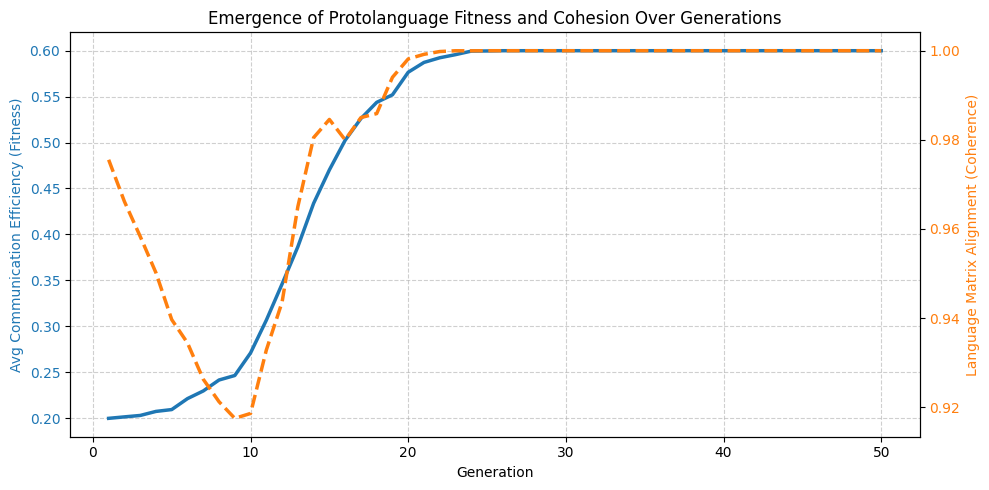

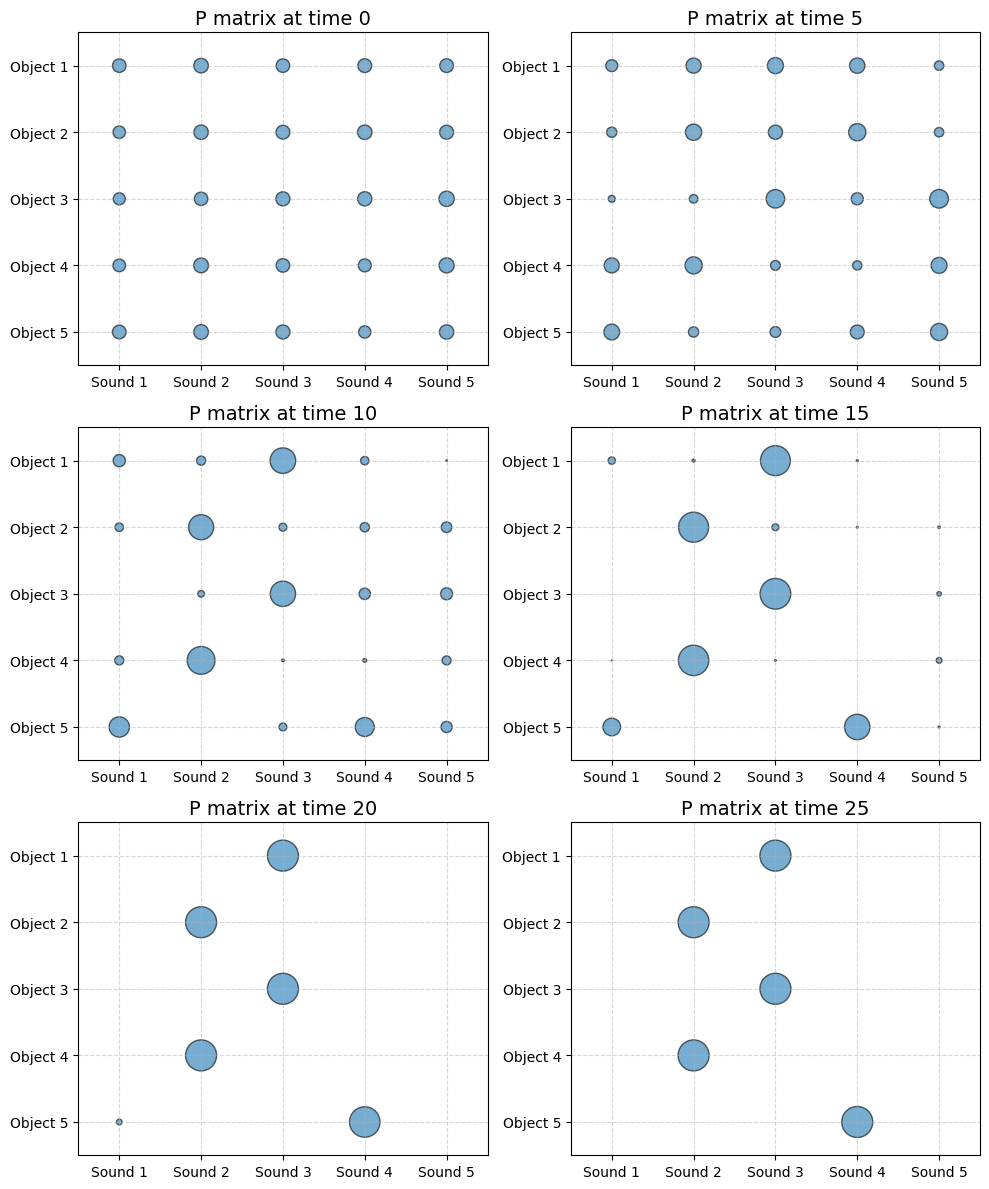

In [6]:
proto_experiment = ProtolanguageSimulation(n_pop=100, n_objects=5, n_signals=5, sample_size=12)
proto_experiment.run_simulation_and_plot(generations=50)

After running the simulation, we notice that from Figure 1 the fitness score and coherence score **move in tandem and eventually converge**. An individual cannot have high fitness unless they are coherent with the group, and the group cannot achieve high average fitness until their languages align. The moment the coherence curve spikes upward is the exact moment the population has collectively "agreed" on which words map to which objects, causing the fitness to maximize simultaneously.

Figure 2 shows how the average of the $P$ matrix across the whole population **converges over generations**. At the beginning, objects are associated randomly with sounds. After generations, each object is associated with one sound. However, sound 2 and sound 3 are used for two objects, whereas sound 1 and sound 5 are not used at all. This solution is suboptimum but evolutionarily stable.

## 3.2 Linguistic Error Limits

In a simple protolanguage, each object is represented by a single sound. If there are more objects, the system needs more sounds. The paper introduces the concept of communication errors by recognizing that sounds are not always perceived perfectly. Similar sounds may be confused with one another, particularly in primitive communication systems. 

The probability that sound $i$ is perceived as sound $j$ is represented by the perception matrix $U$. A simple way to model acoustic similarity is: 

$$U_{ij} = \frac{s_{ij}}{\sum_{k=1}^{m}s_{ik}}$$

where $s_{ij}$ is the similarity between sounds $i$ and $j$. 

In the adaptive dynamics simulation, similarity is modeled using the exponential function: 

$$s_{ij} = e^{-\alpha |x_i-x_j|}$$

Here, $x_i$ and $x_j$ are positions of sounds on a continuous acoustic spectrum, and $\alpha$ controls how quickly similarity decreases with acoustic distance.

Note that in this simulation the fitness score is calculated slightly differently becasue not all concepts are equally important. **Objects are weighted by relevance ($a_0 > a_1 > a_2 \dots$).** The total fitness is calculated by:

$$F(L, L') = \frac{1}{2} \sum_{i} a_i \left[ \sum_{j} \sum_{k} p_{ij} u_{jk} q'_{ki} + \sum_{j} \sum_{k} p'_{ij} u_{jk} q_{ki} \right]$$

Where the additional element $u_{jk}$ represents the probability that sound $j$ is perceived as sound $k$.

Fundamentally, as the number of sounds increases, the probability of misunderstanding also increases. Therefore, adding more sounds does not always improve communication.

This creates a fundamental tradeoff:

- More signals increase vocabulary size.
- More signals also increase communication errors.

Eventually, communication efficiency reaches a maximum and begins to decline. This phenomenon is referred to as the **linguistic error limit**. The existence of this limit implies that simply adding more signals cannot indefinitely increase communication capacity.

The paper also assumes that a language will face **mutation** during its evolution. Here, the mutation simulates linguistic drift and neural errors by doing three things:

1. Continuous Noise: Every entry in matrix $P$ is nudged up or down by a random fraction (between $-0.02$ and $+0.02$). This represents subtle variations in how a word is pronounced.
2. Structural Snapping: With a $0.5\%$ probability, a random association is completely broken (0.0) or totally hardened (1.0).
3. Linguistic Decay: With a $0.2\%$ probability, entire rows or columns are zeroed out, simulating the complete loss of a vocabulary word or an acoustic channel.

A mutant language successfully invades and replaces the resident if and only if it yields higher utility both when communicating with itself and with the population:

$$F(L', L') > F(L', L) > F(L, L)$$


Running Adaptive Dynamics Simulation...
Saved evolutionary_language_game_optimization_20_40.png to: /Users/timchan/Downloads/Reproducible-Research-project-2026/output/evolutionary_language_game_optimization_20_40.png
Saved optimized_active_language_profile_20_40.png to: /Users/timchan/Downloads/Reproducible-Research-project-2026/output/optimized_active_language_profile_20_40.png


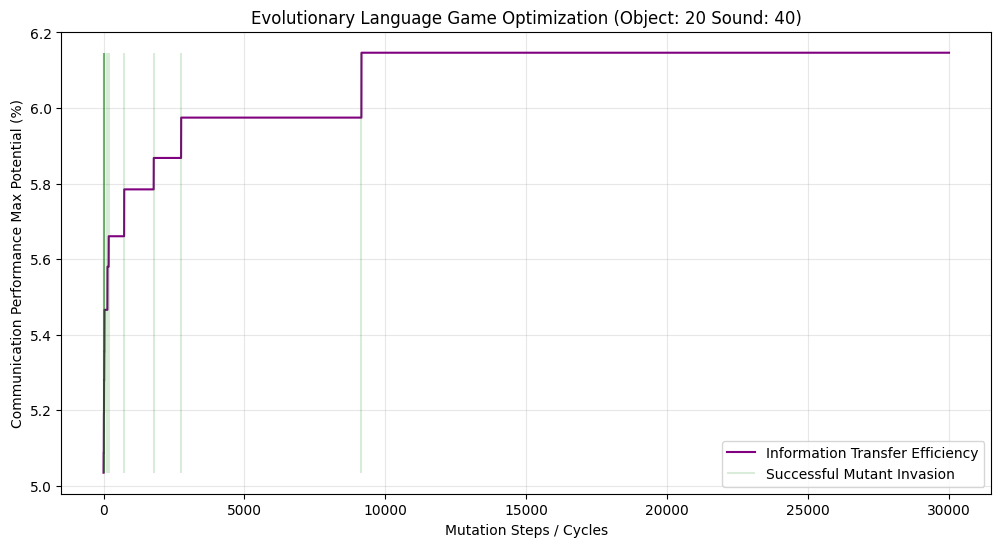

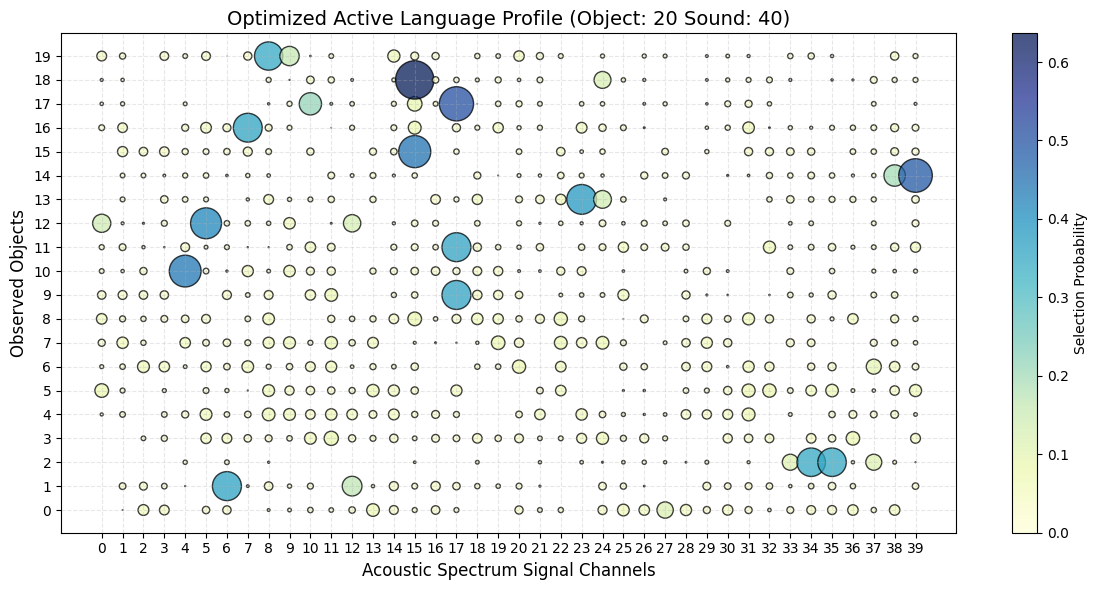

In [7]:
adaptive_experiment = AdaptiveDynamicsSimulation(alpha=2.5, n_objects=20, n_sounds=40)
adaptive_experiment.run_simulation_and_plot(total_mutations=30000)

Figure 1 shows the evolutionary trajectory of the population's communication system over 30,000 mutation cycles. The purple line tracks the information transfer efficiency, which measures how effectively the population communicates under acoustic noise constraints, displaying a distinct step-like pattern where sharp climbs represent periods of rapid linguistic optimization. The green vertical lines mark the precise instances of a successful mutant invasion, where an altered language matrix outcompeted the established resident matrix. These green lines are dense early in the simulation as the initial, chaotic language configuration quickly discovers easy efficiency gains, but they become increasingly sparse over time as the system approaches a highly optimized local or global peak where superior mutations become mathematically rare.

Figure 2 provides a structural blueprint of the final optimized language strategy by visualizing the active communication matrix ($P$). Rather than displaying a random distribution or a perfectly uniform diagonal line, the plot reveals distinct clusters and large horizontal gaps where specific acoustic channels are left completely unused to serve as protective phonetic buffers. There are 20 objects and 40 sounds, but evolution leads to a language that uses only a subset of sounds to describe a subset of objects. By concentrating selection probabilities into larger circles that are maximally separated across the number line, natural selection has successfully driven linguistic drift to engineered acoustic distinctiveness, effectively minimizing systemic misunderstandings while maximizing semantic transfer.


## 3.3 Word Formation

The paper argues that word formation is the solution to the error limit. Instead of assigning one sound to each object, a language can combine sounds into words.

If a language has $m$ sounds and each word has length $l$, then the number of possible words is $m^l$. For example, if $m=10$ and $l=2$, the language can form $10^2 = 100$ possible words. This means that a relatively small number of sounds can generate a much larger number of communicative units.

Without word formation, the approximate payoff for a protolanguage with $m$ sounds is:

$$F(m) = \frac{\sum_{i=1}^{m}a_i}{1+(m-1)\epsilon}$$

where $a_i$ is the value of object $i$ and $\epsilon$ is the probability of confusing one sound with another.

With word formation using words of length $2$, the payoff becomes 

$$F(m,2) = \frac{\sum_{i=1}^{M}a_i}{[1+(m-1)\epsilon]^2}$$

where $M = \min(m^2,n)$ and $n$ is the total number of objects.

This shows why word formation is powerful. The error penalty increases because each word has multiple sounds, but the vocabulary capacity increases much faster because the number of possible words grows as $m^2$.

Saved word_formation_simulation.png to: /Users/timchan/Downloads/Reproducible-Research-project-2026/output/word_formation_simulation.png


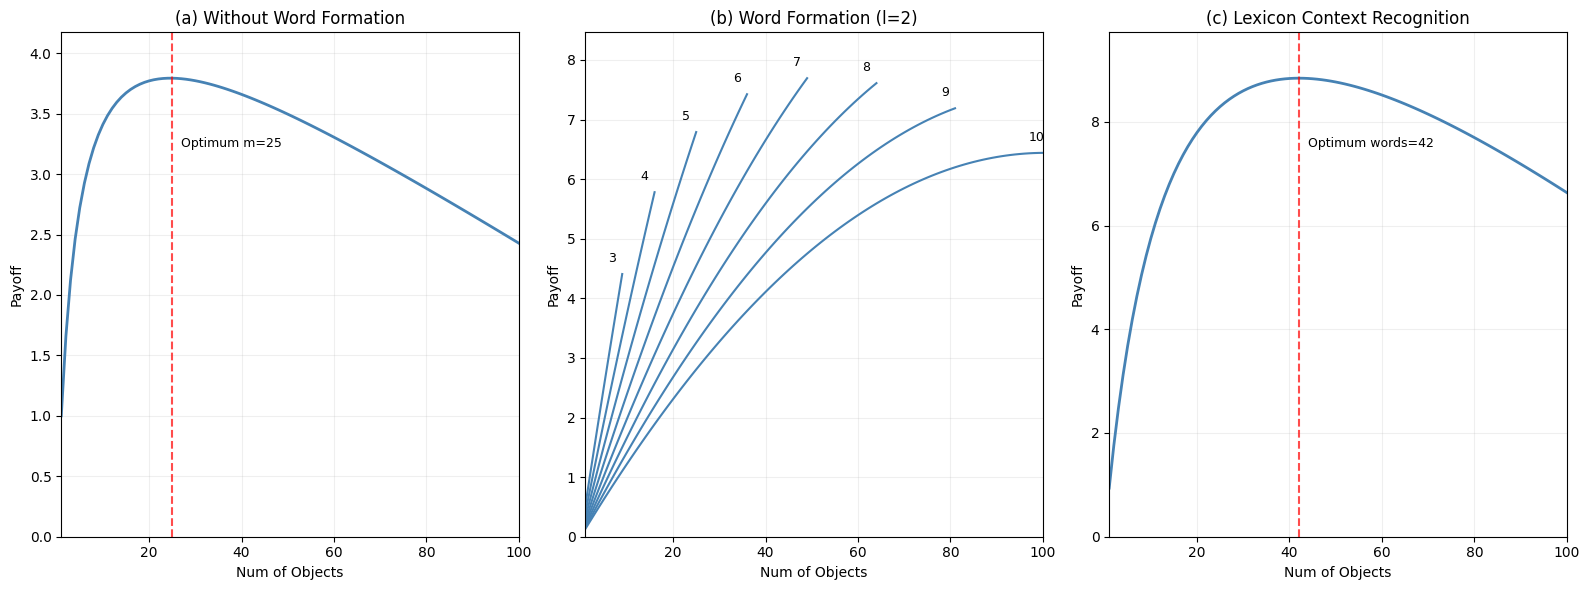

In [8]:
word_formation_simulation = WordFormationSimulation(n_objects=100, epsilon=0.2)
word_formation_simulation.run_simulation_and_plot()

Panel (a) shows that simple protolanguages are constrained by a linguistic error limit. Increasing the number of sounds initially improves communication, but eventually leads to diminishing returns because of perceptual confusion. Without word formation, each object is described by one sound. The maximum payoff is obtained if the 25 most valuable objects are being described by individual sounds. All other objects are ignored. 

Panel (b) demonstrates that word formation fundamentally changes the situation. By combining sounds into words, the language gains access to a vastly larger vocabulary without requiring a proportional increase in the number of distinguishable sounds.  In this model, correct identification of a word requires correct understanding of each individual sound. The figure shows the payoff curves for languages that have m = 2 to 10 different sounds. For each language, it is best to make use of the whole repertoire, that is, to use all m^2 combinations as words. The maximum payoff is achieved for m = 7, which leads to 49 words describing 49 objects

Panel (c) shows that contextual recognition can further improve communication efficiency by allowing listeners to use lexical knowledge when interpreting words. A more sophisticated theory of word recognition assumes that correct understanding of a word is based on matching the perceived sequence of sounds to all combinations that are thought to be part of the lexicon of the language. 

The overall conclusion is consistent with the central claim of Nowak and Krakauer (1999): the evolution of language required a transition from simple signal-object mappings to combinatorial word systems. Word formation transforms communication from a limited analog signaling system into a scalable digital system capable of supporting an essentially unlimited vocabulary.

# 4. Summary

The simulations collectively reproduce several of the most important insights proposed by Nowak and Krakauer.

First, shared communication systems can emerge spontaneously through evolutionary processes. No central authority or predefined language structure is required. Second, communication systems face intrinsic limitations due to perceptual uncertainty. Increasing the number of available signals eventually produces diminishing returns because confusion becomes more frequent. Third, combinatorial structure provides a powerful solution to this problem. Rather than expanding vocabulary through additional sounds, languages expand vocabulary through combinations of sounds.

These findings provide a plausible evolutionary pathway from primitive communication systems to the highly expressive languages observed in humans today.
